# Homework 10a - Modeling: Linear Regression

**Course:** FRE 5040 Applied Financial Engineering
**Dataset:** the Stage 09 feature matrix for the Portfolio Drift Monitor. Eleven
features, one target, built from a year of real VTI / VXUS / BND closes.

The starter offered synthetic factor data. This uses the project's own, because the
question this stage asks is "do I trust this model", and that only has an answer for a
model of something real.

| Section | Requirement it covers |
|---|---|
| 2 | train/test split |
| 3 | fit, predict, R² and RMSE |
| 4 | the four assumptions, one plot and one test each |
| 5 | coefficients, and explanation versus prediction |
| 6 | stretch: transformed features, and the automated variant sweep |
| 7 | do I trust this model, and for what purpose |

Helper module: `src/modeling.py`. Diagnostics are computed there from numpy and scipy
rather than pulled from statsmodels, which is not in this environment.

Run order: Kernel -> Restart Kernel and Run All Cells.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy scipy pandas seaborn matplotlib scikit-learn

## 0. Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import features as F
from src import modeling as M

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
np.random.seed(7)                     # nothing here is random; set for reproducibility anyway

RAW = Path('data/raw')
PROC = Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)

TARGET_WEIGHTS = {'VTI': 0.60, 'VXUS': 0.30, 'BND': 0.10}
HORIZON = 21
TARGET = f'y_absdrift_fwd_{HORIZON}'

print('working from:', ROOT.name)
print('pandas', pd.__version__)

working from: homework10a
pandas 2.3.3


## 1. The data

Rebuilt from the raw prices through `src/features.py`, so this notebook depends on the
Stage 09 code rather than on a CSV someone might have edited.

The target is **absolute drift 21 trading days ahead**. Stage 09 chose that horizon
deliberately: today's drift predicts tomorrow's at 0.979, so a one-day target would be
answered correctly by "the same as today" and would teach a model nothing.

In [3]:
prices = pd.read_csv(RAW / 'portfolio_prices.csv', parse_dates=['date'])
matrix = F.build_feature_matrix(prices, TARGET_WEIGHTS, prices_raw=prices, horizon=HORIZON)

data = (matrix[['date', 'ticker'] + F.MODEL_FEATURES + [TARGET]]
        .dropna()
        .sort_values(['ticker', 'date'])
        .reset_index(drop=True))

# Two transformed columns for the stretch section, built now so every variant in the
# sweep sees the same frame.
data['abs_drift_sq'] = data['abs_drift'] ** 2
data['vol_x_absdrift'] = data['vol_21'] * data['abs_drift']

print('model-ready:', data.shape)
print('window     :', data['date'].min().date(), '->', data['date'].max().date())
data.head(3)

model-ready: (627, 16)
window     : 2025-09-30 -> 2026-07-30


,date,ticker,abs_drift,abs_drift_rel,drift_chg_1,drift_chg_5,drift_slope_21,ret_1,vol_21,eq_bond_spread_21,ticker_VTI,ticker_VXUS,ticker_BND,y_absdrift_fwd_21,abs_drift_sq,vol_x_absdrift
0,2025-09-30,BND,0.200645,2.006450,-0.035725,-0.014572,-2.937197,-0.000403,4.046357,27.229207,0,0,1,0.397181,0.040258,0.811881
1,2025-10-01,BND,0.247308,2.473080,-0.046663,-0.082352,-2.964196,-0.000672,3.485838,35.446592,0,0,1,0.331397,0.061161,0.862076
2,2025-10-02,BND,0.251933,2.519333,-0.004625,-0.126299,-2.929555,0.001076,3.354151,35.762594,0,0,1,0.350078,0.063470,0.845022


### One column has to go before anything is fitted

Stage 09 built **three** one-hot columns, one per fund, and recorded that `drop_first`
was "a Stage 10 decision, not a Stage 09 one". This is Stage 10, so here is the decision.

Three indicator columns sum to 1 on every row, which is exactly what the intercept
already is. The design matrix is therefore rank deficient: infinitely many coefficient
vectors fit equally well, and standard errors are undefined. `sklearn` hides this by
solving with a pseudo-inverse and returning *a* answer without complaint.
`src/modeling.fit_ols` raises instead.

**BND is dropped and becomes the reference fund.** Every `ticker_` coefficient below
therefore reads as "compared with BND".

In [4]:
FEATURES = [c for c in F.MODEL_FEATURES if c != 'ticker_BND']

design_all = np.column_stack([np.ones(len(data)), data[F.MODEL_FEATURES].to_numpy(float)])
design_drop = np.column_stack([np.ones(len(data)), data[FEATURES].to_numpy(float)])

for name, dm in [('all three dummies', design_all), ('BND dropped', design_drop)]:
    rank, cols = np.linalg.matrix_rank(dm), dm.shape[1]
    print(f'  {name:<20} {cols} columns, rank {rank}  '
          f'{"RANK DEFICIENT" if rank < cols else "full rank"}')

print()
print(f'fitting with {len(FEATURES)} features, BND as the reference fund')

  all three dummies    12 columns, rank 11  RANK DEFICIENT
  BND dropped          11 columns, rank 11  full rank

fitting with 10 features, BND as the reference fund


## 2. The split

**Chronological, and split on dates rather than rows.** Stage 08 established that the
drift is a trend, correlating with time at -0.93 for BND. On a trended series a random
split puts rows from *after* a test row into the training set, so the model is asked
about a regime it has already seen.

Splitting on dates rather than rows matters for a panel: a row-based cut at 80% would
put VTI in train and BND in test for the same day, leaking that day's market conditions
across the boundary.

In [5]:
train, test, cut = M.chronological_split(data, test_frac=0.2)

print(f'cut date : {cut.date()}')
print(f'train    : {len(train)} rows, {train["date"].min().date()} -> {train["date"].max().date()}')
print(f'test     : {len(test)} rows, {test["date"].min().date()} -> {test["date"].max().date()}')
print()
summary = pd.DataFrame({
    'train': train[TARGET].describe(),
    'test': test[TARGET].describe(),
}).round(3)
print(summary.to_string())

cut date : 2026-06-01
train    : 501 rows, 2025-09-30 -> 2026-05-29
test     : 126 rows, 2026-06-01 -> 2026-07-30

         train     test
count  501.000  126.000
mean     0.726    1.033
std      0.521    0.422
min      0.002    0.305
25%      0.313    0.706
50%      0.633    0.917
75%      1.170    1.424
max      2.233    1.769


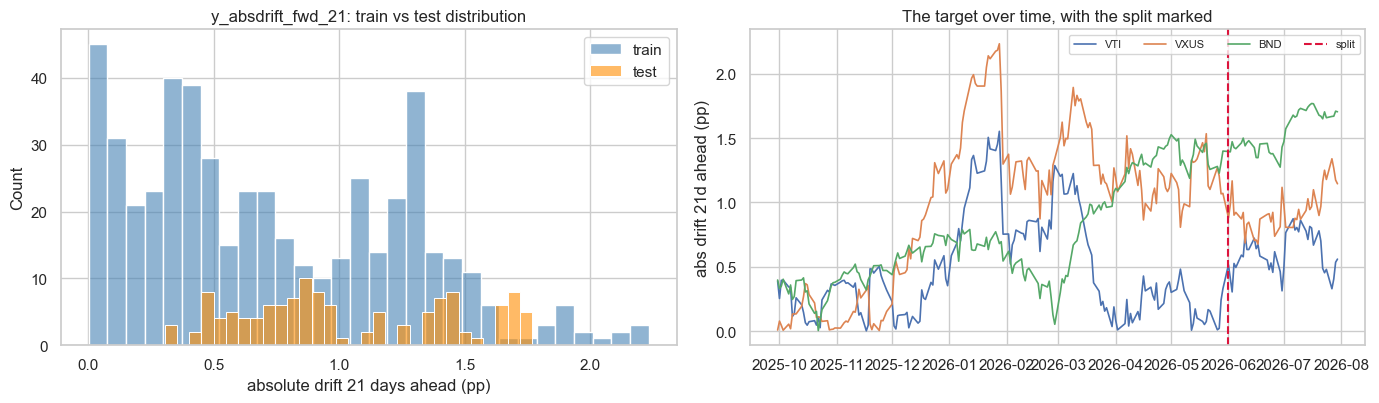

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

sns.histplot(train[TARGET], bins=30, ax=axes[0], label='train', alpha=0.6, color='steelblue')
sns.histplot(test[TARGET], bins=30, ax=axes[0], label='test', alpha=0.6, color='darkorange')
axes[0].set_title(f'{TARGET}: train vs test distribution')
axes[0].set_xlabel('absolute drift 21 days ahead (pp)')
axes[0].legend()

for t in ['VTI', 'VXUS', 'BND']:
    p = data[data['ticker'] == t]
    axes[1].plot(p['date'], p[TARGET], linewidth=1.2, label=t)
axes[1].axvline(cut, color='crimson', linestyle='--', linewidth=1.5, label='split')
axes[1].set_title('The target over time, with the split marked')
axes[1].set_ylabel('abs drift 21d ahead (pp)')
axes[1].legend(ncol=4, fontsize=8)

fig.tight_layout()
plt.show()

**What?** The test period is not a random sample of the training period. Train has mean
0.726 and spans 0.002 to 2.233. Test has mean **1.033** and spans 0.305 to 1.769: higher
on average, and narrower.

**So what?** The test set is a genuinely different regime, which is the honest situation
a chronological split is supposed to reproduce. It also means the usual expectation, that
a test score will be worse than a training score, does not have to hold here. Section 3
finds it does not, and section 3's commentary is about why.

**Now what?** Every score below is reported against baselines rather than on its own,
because on a shifted distribution an R² in isolation is not interpretable.

## 3. The baseline fit

In [7]:
fit = M.fit_ols(train[FEATURES].to_numpy(), train[TARGET].to_numpy(), FEATURES)

print(f'train R²     {fit["r_squared"]:.4f}')
print(f'adjusted R²  {fit["adj_r_squared"]:.4f}')
print(f'n = {fit["n"]}, parameters = {fit["k"]}')
print()
fit['coefficients'].round(4)

/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y


train R²     0.4578
adjusted R²  0.4468
n = 501, parameters = 11



/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta


,coef,std_err,t,p_value
intercept,0.2818,0.0626,4.5015,0.0000
abs_drift,0.4543,0.0771,5.8916,0.0000
abs_drift_rel,0.0419,0.0151,2.7780,0.0057
drift_chg_1,0.0953,0.1918,0.4969,0.6195
drift_chg_5,-0.0330,0.0818,-0.4032,0.6870
drift_slope_21,-0.0069,0.0028,-2.4390,0.0151
ret_1,-2.8070,2.5454,-1.1028,0.2707
vol_21,-0.0210,0.0055,-3.8226,0.0001
eq_bond_spread_21,0.0001,0.0005,0.1627,0.8708
ticker_VTI,0.2203,0.0892,2.4692,0.0139


In [8]:
pred_test = M.predict_ols(fit['beta'], test[FEATURES].to_numpy())

scores = M.evaluate(test[TARGET], pred_test)
baselines = M.compare_baselines(train, test, TARGET, naive_col='abs_drift')

rows = [{'model': 'linear regression (11 params)', **scores}]
rows.append({'model': 'persistence (today\'s abs_drift)', **baselines['persistence']})
rows.append({'model': 'train mean (a flat line)', **baselines['train_mean']})
comparison = pd.DataFrame(rows).set_index('model').round(4)
comparison

/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:129: RuntimeWarning: divide by zero encountered in matmul
  return np.column_stack([np.ones(len(X)), X]) @ np.asarray(beta, dtype=float)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:129: RuntimeWarning: overflow encountered in matmul
  return np.column_stack([np.ones(len(X)), X]) @ np.asarray(beta, dtype=float)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:129: RuntimeWarning: invalid value encountered in matmul
  return np.column_stack([np.ones(len(X)), X]) @ np.asarray(beta, dtype=float)


,r2,rmse,mae,n
model,,,,
linear regression (11 params),0.6917,0.2333,0.1915,126
persistence (today's abs_drift),0.5024,0.2964,0.2372,126
train mean (a flat line),-0.5331,0.5203,0.4037,126


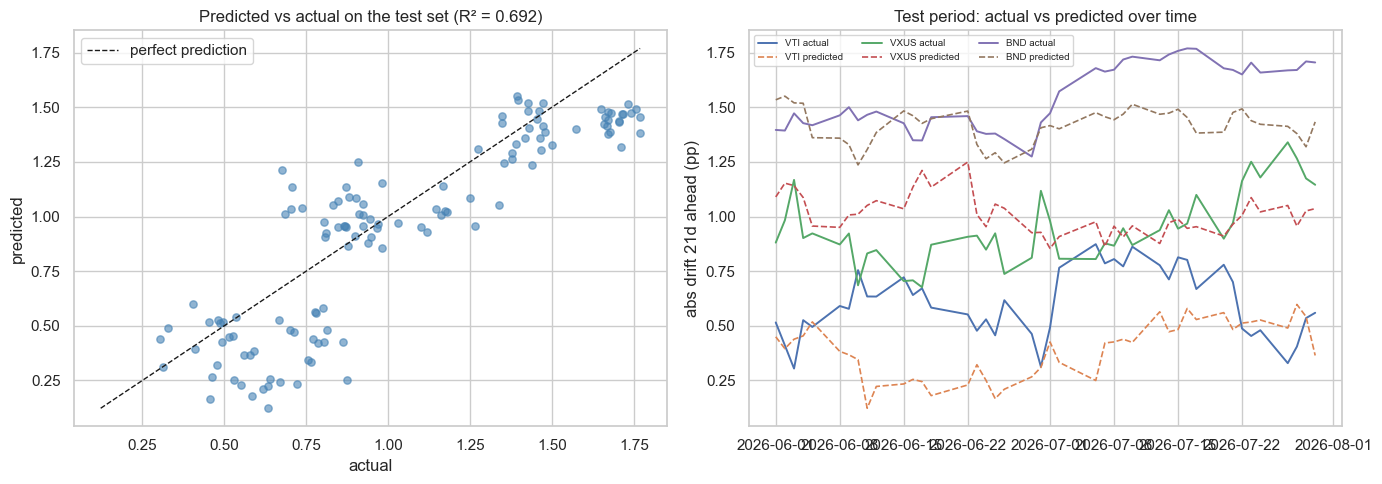

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test[TARGET], pred_test, alpha=0.6, s=28, color='steelblue')
lims = [min(test[TARGET].min(), pred_test.min()), max(test[TARGET].max(), pred_test.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='perfect prediction')
axes[0].set_xlabel('actual'); axes[0].set_ylabel('predicted')
axes[0].set_title(f'Predicted vs actual on the test set (R² = {scores["r2"]:.3f})')
axes[0].legend()

for t in ['VTI', 'VXUS', 'BND']:
    mask = (test['ticker'] == t).to_numpy()
    axes[1].plot(test['date'][mask], test[TARGET][mask], linewidth=1.4, label=f'{t} actual')
    axes[1].plot(test['date'][mask], pred_test[mask], linewidth=1.2, linestyle='--',
                 label=f'{t} predicted')
axes[1].set_title('Test period: actual vs predicted over time')
axes[1].set_ylabel('abs drift 21d ahead (pp)')
axes[1].legend(ncol=3, fontsize=7)

fig.tight_layout()
plt.show()

**Metrics, in context.** Test R² is **0.692** and test RMSE **0.233pp**. On its own that
reads well. Against the baselines it reads differently:

| Predictor | test R² | test RMSE |
|---|---|---|
| linear regression | **0.692** | **0.233** |
| persistence, predict today's drift | 0.502 | 0.296 |
| train mean, a flat line | -0.533 | 0.520 |

The flat line scores *negative*, which is not a bug: R² is defined against the mean of
the test set, and the training mean is well below it, so a horizontal line at the wrong
height is worse than useless.

**The number that matters is the middle row.** Persistence already achieves 0.502 by
doing nothing but assuming today's drift persists. The model's contribution is the gap
from 0.502 to 0.692, and its RMSE improvement is 0.296 to 0.233, about 21%. Real, and
much smaller than the headline R² suggests.

**What RMSE means here.** 0.233 percentage points of drift. The amber threshold is 3pp
and the worst drift the year produced was 2.23pp, so a typical error is roughly a tenth
of the range the monitor cares about. For ranking which fund needs attention next month,
that is useful. For deciding whether a specific fund will cross a line, it is not, and
section 7 returns to that.

In [10]:
# The cautionary comparison: what a random split would have reported.
from sklearn.model_selection import train_test_split as sk_split

Xr_tr, Xr_te, yr_tr, yr_te = sk_split(data[FEATURES], data[TARGET],
                                      test_size=0.2, shuffle=True, random_state=42)
rfit = M.fit_ols(Xr_tr.to_numpy(), yr_tr.to_numpy(), FEATURES)
rpred = M.predict_ols(rfit['beta'], Xr_te.to_numpy())

split_table = pd.DataFrame([
    {'split': 'chronological (used)', 'train_r2': fit['r_squared'],
     'test_r2': scores['r2'], 'test_rmse': scores['rmse']},
    {'split': 'random (shuffled)', 'train_r2': rfit['r_squared'],
     'test_r2': M.evaluate(yr_te, rpred)['r2'], 'test_rmse': M.evaluate(yr_te, rpred)['rmse']},
]).set_index('split').round(4)
split_table

/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeW

,train_r2,test_r2,test_rmse
split,,,
chronological (used),0.4578,0.6917,0.2333
random (shuffled),0.5312,0.5008,0.3476


### The prediction Stages 08 and 09 made was wrong, and the reason is the interesting part

Both earlier stages wrote down the same expectation, in almost the same words:

> Split chronologically and expect the score to look worse than a random split would
> give, because a random split on a trended series leaks.

The first half is right and the second half is backwards. Measured:

| Split | train R² | test R² | test RMSE |
|---|---|---|---|
| chronological | 0.458 | **0.692** | **0.233** |
| random | 0.556 | 0.378 | 0.392 |

The chronological split scores **better** on test, not worse. It also scores better on
test than on its own training data, which normally means a bug.

**Why it happens.** The reasoning behind the prediction was "the test set is out of
distribution, so it will be harder". Out of distribution does not imply harder. The last
20% of this window is the period where the trend is most established and BND's drift is
close to a straight line, so the target there is *narrower and more predictable* than in
the early period. Test R² above train R² is not a leak, it is an easier test set. The
distribution table in section 2 shows exactly that: test range 0.305 to 1.769 against a
train range of 0.002 to 2.233.

The random split scores worse because shuffling puts the noisy early period on both
sides of the boundary, so it has to predict hard rows *and* trains on a mixture.

**What this does not mean.** It does not mean a random split is safe here. Its optimism
is still real and would show up on data where the regimes differ the other way. The
lesson is narrower and more useful: a chronological split does not automatically produce
a pessimistic number, and "my test score went up" is a result to explain rather than to
celebrate or to debug away.

This correction belongs in `docs/eda.md` and `docs/features.md`, both of which currently
state the expectation as though it were established.

## 4. The four assumptions

Fitting takes one line. This section is the assignment.

In [11]:
diag = M.regression_diagnostics(fit, train[FEATURES].to_numpy(),
                                group_labels=train['ticker'], horizon=HORIZON)
resid = fit['residuals']
fitted = fit['fitted']
print('diagnostics computed on the %d training residuals' % len(resid))

diagnostics computed on the 501 training residuals


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:179: RuntimeWarning: divide by zero encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:179: RuntimeWarning: overflow encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:179: RuntimeWarning: invalid value encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:180: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:180: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/B

### 4.1 Linearity

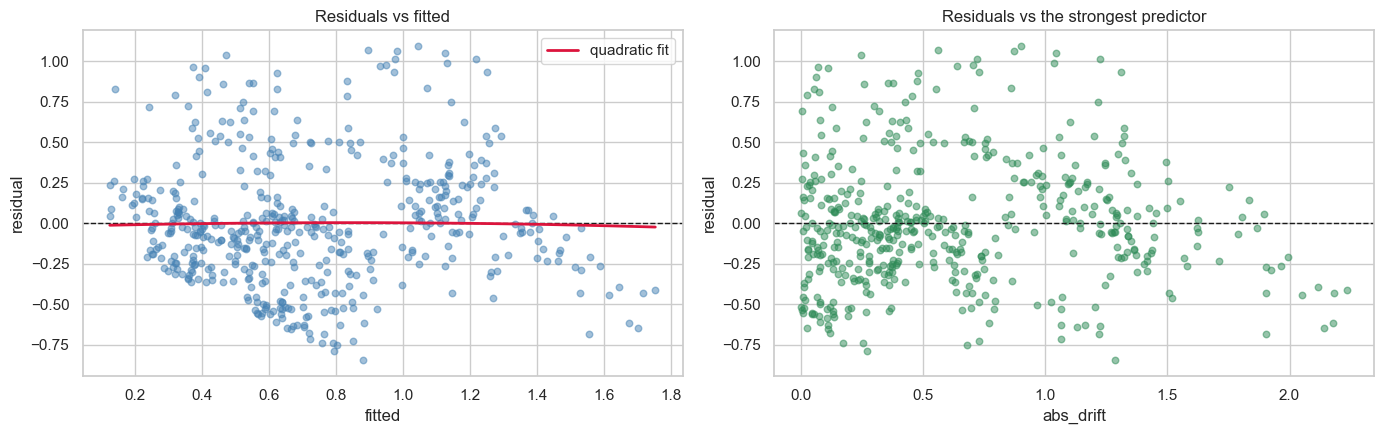

correlation(residual, fitted) = 0.0000   (0 by construction for OLS)
quadratic term of resid ~ fitted = -0.0319


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].scatter(fitted, resid, alpha=0.5, s=22, color='steelblue')
axes[0].axhline(0, color='k', linestyle='--', linewidth=1)
smooth = np.poly1d(np.polyfit(fitted, resid, 2))
xs = np.linspace(fitted.min(), fitted.max(), 100)
axes[0].plot(xs, smooth(xs), color='crimson', linewidth=2, label='quadratic fit')
axes[0].set_xlabel('fitted'); axes[0].set_ylabel('residual')
axes[0].set_title('Residuals vs fitted')
axes[0].legend()

axes[1].scatter(train['abs_drift'], resid, alpha=0.5, s=22, color='seagreen')
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_xlabel('abs_drift'); axes[1].set_ylabel('residual')
axes[1].set_title('Residuals vs the strongest predictor')

fig.tight_layout()
plt.show()

print('correlation(residual, fitted) = %.4f   (0 by construction for OLS)'
      % diag['linearity']['resid_fitted_corr'])
print('quadratic term of resid ~ fitted = %+.4f' % diag['linearity']['quadratic_curvature'])

**Verdict: broadly satisfied, with mild curvature.**

The quadratic term fitted to residuals against fitted values is **-0.032**, which is small
relative to a residual spread of about 0.38. The red curve is close to flat. Residuals
against `abs_drift`, the strongest single predictor, show no obvious fan or arc.

The correlation of residuals with fitted values is exactly 0. That is not evidence of
anything: OLS guarantees it algebraically. It is printed only to make the point that a
diagnostic which cannot fail is not a diagnostic, and the curvature number is the one
doing the work.

Section 6 tests the curvature directly by adding a squared term. The result is not what
the mild curve suggests.

### 4.2 Independence - and this is where the model breaks

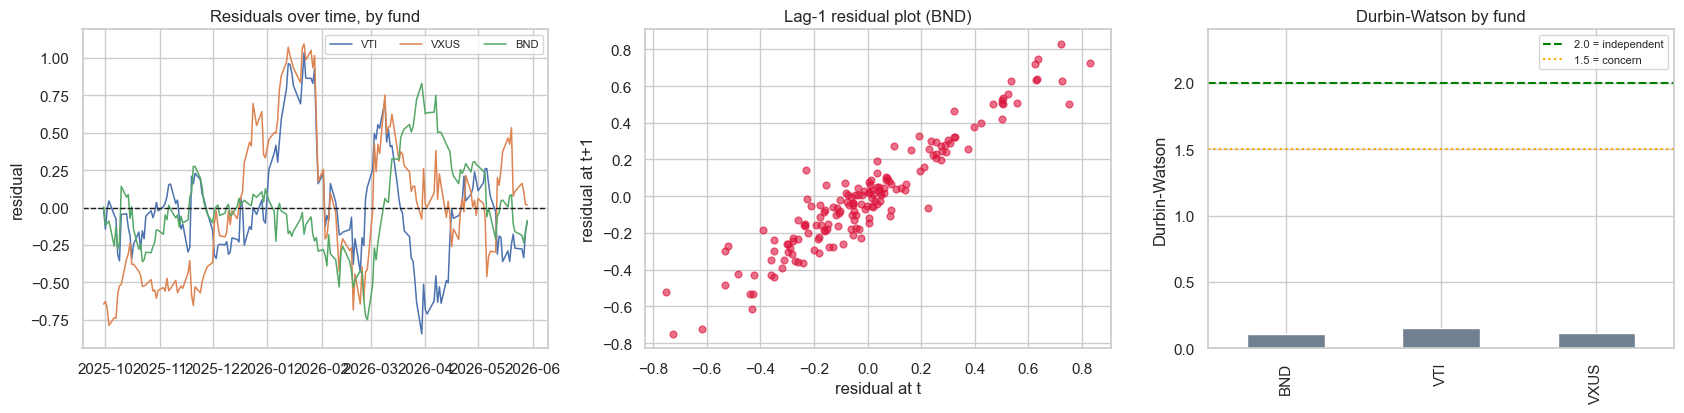

  BND   Durbin-Watson 0.107   lag-1 autocorrelation +0.947
  VTI   Durbin-Watson 0.151   lag-1 autocorrelation +0.924
  VXUS  Durbin-Watson 0.114   lag-1 autocorrelation +0.943
  pooled Durbin-Watson 0.128


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))

train_plot = train.assign(resid=resid)
for t in ['VTI', 'VXUS', 'BND']:
    p = train_plot[train_plot['ticker'] == t]
    axes[0].plot(p['date'], p['resid'], linewidth=1.1, label=t)
axes[0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0].set_title('Residuals over time, by fund')
axes[0].set_ylabel('residual'); axes[0].legend(ncol=3, fontsize=8)

bnd = train_plot[train_plot['ticker'] == 'BND']['resid'].to_numpy()
axes[1].scatter(bnd[:-1], bnd[1:], alpha=0.6, s=24, color='crimson')
axes[1].set_xlabel('residual at t'); axes[1].set_ylabel('residual at t+1')
axes[1].set_title('Lag-1 residual plot (BND)')

dw = pd.Series({g: v['durbin_watson'] for g, v in diag['independence']['by_group'].items()})
dw.plot(kind='bar', ax=axes[2], color='slategrey')
axes[2].axhline(2.0, color='green', linestyle='--', linewidth=1.5, label='2.0 = independent')
axes[2].axhline(1.5, color='orange', linestyle=':', linewidth=1.5, label='1.5 = concern')
axes[2].set_ylim(0, 2.4); axes[2].set_ylabel('Durbin-Watson')
axes[2].set_title('Durbin-Watson by fund'); axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

for g, v in diag['independence']['by_group'].items():
    print(f'  {g:<5} Durbin-Watson {v["durbin_watson"]:.3f}   lag-1 autocorrelation {v["lag1_autocorr"]:+.3f}')
print(f'  pooled Durbin-Watson {diag["independence"]["pooled_durbin_watson"]:.3f}')

In [14]:
eff = diag['effective_sample']
print('How many INDEPENDENT observations does a 21-day forward target really give?')
print()
print(f'  rows in training set        {eff["n_rows"]}')
print(f'  funds                       {eff["n_groups"]}')
print(f'  rows per fund               {eff["rows_per_group"]:.0f}')
print(f'  horizon (trading days)      {eff["horizon"]}')
print(f'  effective obs per fund      {eff["effective_per_group"]:.1f}')
print(f'  effective obs total         {eff["effective_total"]:.0f}')
print()
print(f'  parameters being estimated  {fit["k"]}')
print(f'  effective obs per parameter {eff["effective_total"] / fit["k"]:.1f}')

How many INDEPENDENT observations does a 21-day forward target really give?

  rows in training set        501
  funds                       3
  rows per fund               167
  horizon (trading days)      21
  effective obs per fund      8.0
  effective obs total         24

  parameters being estimated  11
  effective obs per parameter 2.2


**Verdict: violated, severely, and this is the finding of the whole notebook.**

Durbin-Watson runs from 0 to 4, and 2.0 means no autocorrelation. Measured: **0.107 for
BND, 0.114 for VXUS, 0.151 for VTI.** Lag-1 residual autocorrelation is **+0.92 to +0.95**.
The lag-1 scatter is a near-perfect diagonal line. These are not borderline numbers.

**Why, and it is structural rather than fixable.** The target is the drift 21 trading
days ahead. Two consecutive rows share **20 of the 21 days** in their target windows.
They are very nearly the same observation counted twice. The residuals inherit that
overlap, so consecutive residuals are almost the same number.

The consequence is the arithmetic above. 501 training rows, divided by three funds, is
167 rows per fund; divided by the 21-day horizon, that is about **8 genuinely
independent observations per fund, roughly 24 in total**. The model estimates **11
parameters**. That is barely two effective observations per parameter.

**What this invalidates, and what it does not.**

Positive autocorrelation does not bias the coefficients. It biases the *standard errors*
downward, badly, which inflates t statistics and shrinks p-values. So the impressive
column in section 3's coefficient table is the one that has to be thrown away: those
p-values are computed as though there were 501 independent observations, and there are
about 24.

The point predictions survive. The inference does not.

**Could it be fixed?** Not without changing the question. Shortening the horizon reduces
the overlap but Stage 09 showed a 1-day horizon is trivially predictable. Sampling every
21st row removes the overlap and leaves about 8 rows per fund. Newey-West standard errors
would correct the inference without fixing the information shortage. The honest response
at this stage is to report the point predictions, refuse to quote a p-value, and prefer
a model with fewer parameters. Section 6 does the last of those.

### 4.3 Homoscedasticity

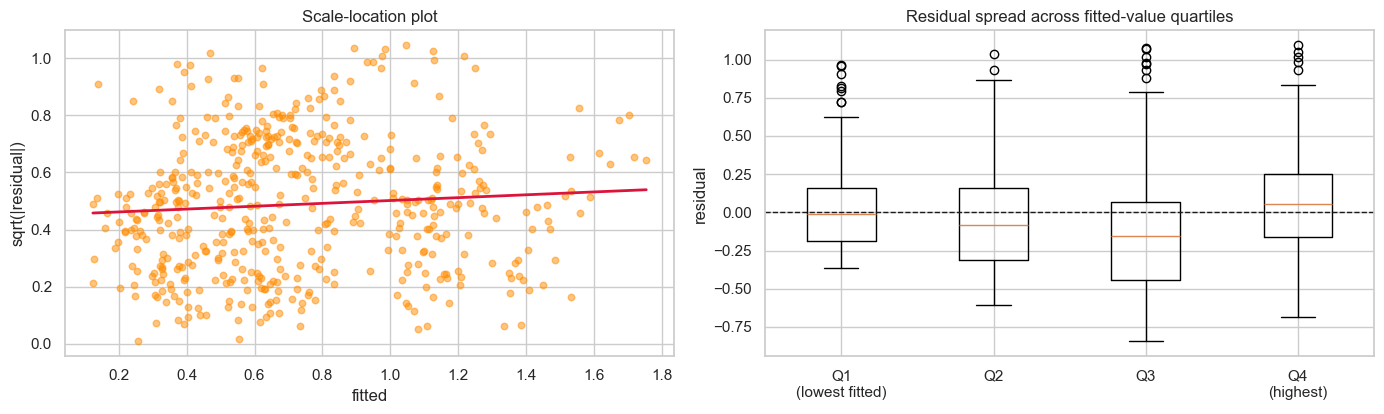

Breusch-Pagan LM = 96.41, df = 10, p = 3.331e-16
residual std, low-fitted half  0.3544
residual std, high-fitted half 0.4099   ratio 1.16


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))

axes[0].scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.5, s=22, color='darkorange')
lo = np.poly1d(np.polyfit(fitted, np.sqrt(np.abs(resid)), 1))
axes[0].plot(xs, lo(xs), color='crimson', linewidth=2)
axes[0].set_xlabel('fitted'); axes[0].set_ylabel('sqrt(|residual|)')
axes[0].set_title('Scale-location plot')

order = np.argsort(fitted)
halves = np.array_split(order, 4)
axes[1].boxplot([resid[h] for h in halves],
                tick_labels=['Q1\n(lowest fitted)', 'Q2', 'Q3', 'Q4\n(highest)'])
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_ylabel('residual')
axes[1].set_title('Residual spread across fitted-value quartiles')

fig.tight_layout()
plt.show()

h = diag['homoscedasticity']
print(f'Breusch-Pagan LM = {h["lm_stat"]:.2f}, df = {h["df"]}, p = {h["p_value"]:.3e}')
print(f'residual std, low-fitted half  {h["resid_std_low_fitted"]:.4f}')
print(f'residual std, high-fitted half {h["resid_std_high_fitted"]:.4f}   ratio {h["ratio"]:.2f}')

**Verdict: violated statistically, mild practically. Both halves matter.**

Breusch-Pagan gives p = 3e-16, which is as decisive as a test gets. But the effect size
is a residual standard deviation of 0.354 in the low-fitted half against 0.410 in the
high-fitted half, a ratio of **1.16**. Errors are 16% larger where predicted drift is
larger.

**So what?** With 501 rows a test will detect a 16% difference easily, and detecting it
is not the same as it mattering. Reporting only the p-value would overstate the problem;
reporting only the ratio would hide that it is systematic rather than noise. Both belong
in the answer.

Sixteen percent is also directionally sensible rather than alarming: a fund that has
drifted further has more room to move, so its future drift is genuinely more variable.
That is a property of the process, not a defect in the model.

**Consequence.** Same as the previous section, and smaller: the standard errors are
somewhat wrong. Given that autocorrelation has already made them wrong by a much larger
factor, this changes nothing about what to trust.

### 4.4 Normality

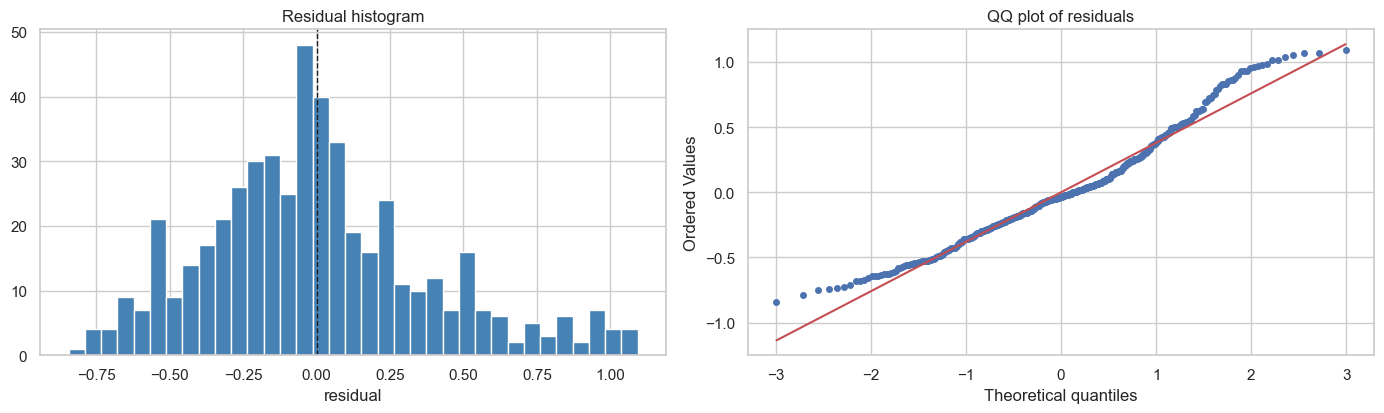

Shapiro-Wilk  W = 0.9709   p = 2.046e-08
Jarque-Bera   30.11      p = 2.893e-07
skew          +0.588
excess kurtosis +0.244   (0 = normal-shaped tails)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))

axes[0].hist(resid, bins=35, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='k', linestyle='--', linewidth=1)
axes[0].set_title('Residual histogram'); axes[0].set_xlabel('residual')

st.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('QQ plot of residuals')
axes[1].get_lines()[0].set_markersize(4)

fig.tight_layout()
plt.show()

nm = diag['normality']
print(f'Shapiro-Wilk  W = {nm["shapiro_W"]:.4f}   p = {nm["shapiro_p"]:.3e}')
print(f'Jarque-Bera   {nm["jarque_bera"]:.2f}      p = {nm["jarque_bera_p"]:.3e}')
print(f'skew          {nm["skew"]:+.3f}')
print(f'excess kurtosis {nm["excess_kurtosis"]:+.3f}   (0 = normal-shaped tails)')

**Verdict: violated, and it is the least consequential of the four.**

Shapiro-Wilk gives W = 0.971 with p = 2e-08, Jarque-Bera agrees. The shape numbers say
how: skew **+0.588**, so a right tail, and excess kurtosis **+0.244**, so tails only
slightly heavier than normal. The QQ plot bends upward at the right end and is otherwise
close to the line.

The right skew has an obvious cause. The target is an absolute value, bounded below at
zero and unbounded above, so its errors cannot be symmetric near the floor.

**So what?** Normality matters for confidence intervals and p-values, not for the point
estimates. The coefficients are unaffected. The intervals are already unusable because of
section 4.2, so this adds a second reason to distrust something that was not trustworthy
anyway.

**Ranking the four failures by how much they should change your behaviour:** independence
first and by a wide margin, then homoscedasticity and normality together and far behind,
then linearity, which is broadly fine.

## 5. Coefficients: what they say, and why the p-value column must not be quoted

,coef,std_err,t,p_value
ticker_VXUS,0.5376,0.0891,6.0322,0.0000
abs_drift,0.4543,0.0771,5.8916,0.0000
intercept,0.2818,0.0626,4.5015,0.0000
vol_21,-0.0210,0.0055,-3.8226,0.0001
abs_drift_rel,0.0419,0.0151,2.7780,0.0057
ticker_VTI,0.2203,0.0892,2.4692,0.0139
drift_slope_21,-0.0069,0.0028,-2.4390,0.0151
ret_1,-2.8070,2.5454,-1.1028,0.2707
drift_chg_1,0.0953,0.1918,0.4969,0.6195
drift_chg_5,-0.0330,0.0818,-0.4032,0.6870


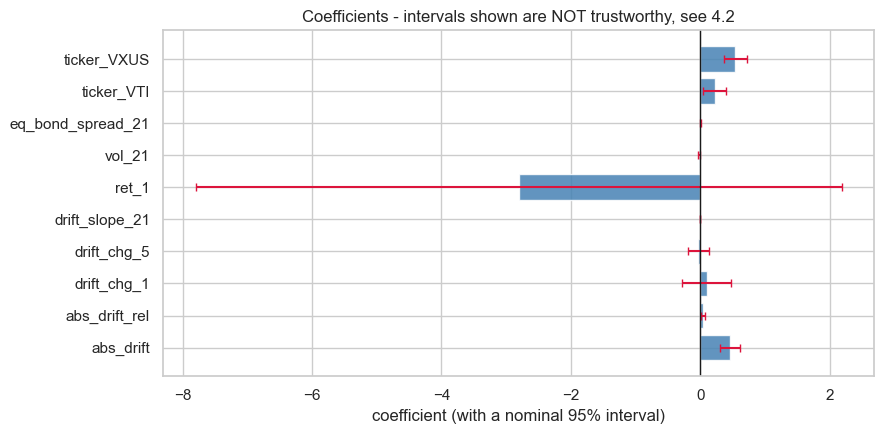

In [17]:
coefs = fit['coefficients'].copy()
coefs['abs_t'] = coefs['t'].abs()
display(coefs.round(4).sort_values('abs_t', ascending=False).drop(columns='abs_t'))

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_c = coefs.drop(index='intercept')
ax.barh(plot_c.index, plot_c['coef'],
        xerr=1.96 * plot_c['std_err'], color='steelblue', alpha=0.85,
        error_kw={'ecolor': 'crimson', 'capsize': 3})
ax.axvline(0, color='k', linewidth=1)
ax.set_xlabel('coefficient (with a nominal 95% interval)')
ax.set_title('Coefficients - intervals shown are NOT trustworthy, see 4.2')
fig.tight_layout()
plt.show()

**What the coefficients say.**

`abs_drift` at **+0.454** is the workhorse: a fund one percentage point further from
target today is expected to be about 0.45pp further from target in a month. Less than
one, so there is mean reversion in it, but well above zero, so drift persists.

`ticker_VXUS` at **+0.538** and `ticker_VTI` at **+0.220**, both relative to BND, say the
two equity funds run further from target than the bond fund even after accounting for
where they are today. That matches Stage 08's finding that VXUS drifts fastest.

`vol_21` at **-0.021** is negative, which is worth pausing on. Higher recent volatility
predicts *less* drift a month out. That inverts the naive story that a more volatile fund
wanders further, and it is consistent with volatility clustering plus mean reversion: a
high-volatility stretch tends to be followed by a correction that pulls the weight back.
It is also the coefficient most likely to be an artifact of one year of data.

`ret_1` at **-2.807** looks enormous and is not comparable to the others. Daily returns
have a standard deviation of about 0.008, so a one-unit change is a 100% daily return
that never happens. **Unscaled coefficients are not effect sizes.** Standardising the
features would make them comparable, and that belongs inside a pipeline fitted on the
training split only, which is Stage 10b's job.

**And now the part that matters.** The table above has a `p_value` column. Several are
below 0.001, and the model's overall fit would test as overwhelmingly significant.

**None of it can be quoted.** Those figures assume 501 independent observations. Section
4.2 established there are about 24. The standard errors are too small by roughly the
square root of that ratio, so the t statistics are inflated several-fold. The error bars
drawn above are correspondingly far too narrow, and the plot title says so.

This is the explanation-versus-prediction distinction in its concrete form. As
**prediction**, the model is usable and section 3 measured how usable. As **explanation**,
it cannot support a claim that any individual coefficient differs from zero, because the
data does not contain enough independent information to make that claim.

## 6. Stretch: transformed features, and an automated sweep

The optional task is a transformed feature. Rather than adding one and reporting whether
it helped, this runs six variants through the same split and metric set, which is also
what the project instructions mean by "automate the modeling process so you can auto-try
the model with some variations".

Adding `abs_drift²` keeps this a **linear regression**. Linear means linear in the
coefficients, not in the predictors. `y = β₀ + β₁x + β₂x²` is fit by exactly the same
least-squares algebra as `y = β₀ + β₁x`.

In [18]:
VARIANTS = {
    'baseline (all 10)':   FEATURES,
    'drift only':          ['abs_drift', 'abs_drift_rel', 'drift_chg_1',
                            'drift_chg_5', 'drift_slope_21'],
    'no fund dummies':     [c for c in FEATURES if not c.startswith('ticker_')],
    'abs_drift alone':     ['abs_drift'],
    '+ abs_drift squared': FEATURES + ['abs_drift_sq'],
    '+ squared + interaction': FEATURES + ['abs_drift_sq', 'vol_x_absdrift'],
}

sweep, sweep_fits = M.auto_try(train, test, TARGET, VARIANTS, horizon=HORIZON)
sweep

/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/homework/homework10a/src/modeling.py:103: RuntimeW

,n_features,train_r2,test_r2,train_rmse,test_rmse,test_mae,overfit_gap,durbin_watson
variant,,,,,,,,
drift only,5,0.3820,0.7474,0.4091,0.2112,0.1759,-0.3653,0.1052
no fund dummies,8,0.3851,0.7284,0.4081,0.2190,0.1832,-0.3433,0.1096
baseline (all 10),10,0.4578,0.6917,0.3832,0.2333,0.1915,-0.2338,0.1277
+ abs_drift squared,11,0.4915,0.6015,0.3711,0.2653,0.2114,-0.1100,0.1466
abs_drift alone,1,0.3624,0.5404,0.4156,0.2849,0.2388,-0.1780,0.1034
+ squared + interaction,12,0.5015,0.4943,0.3674,0.2988,0.2343,0.0073,0.1588


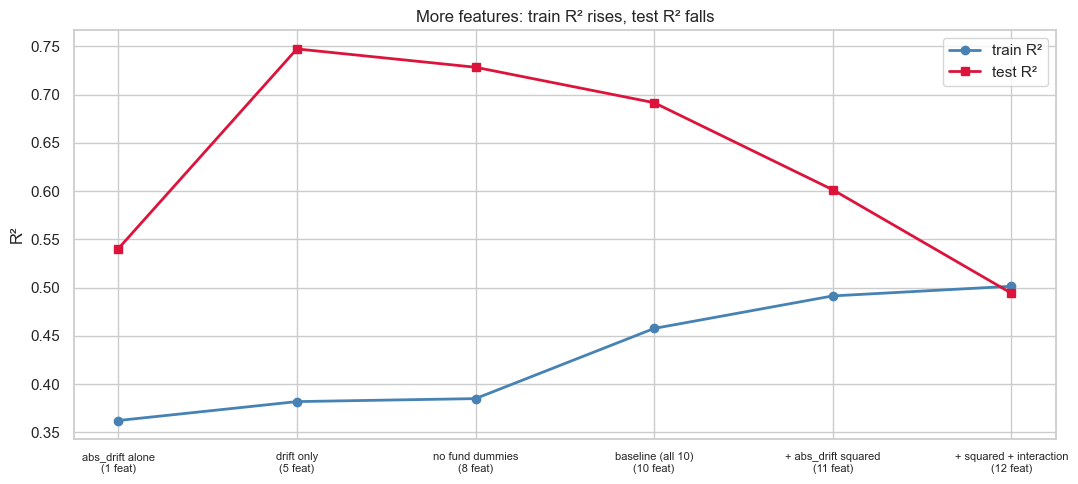

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
order = sweep.sort_values('n_features').index
x = np.arange(len(order))
ax.plot(x, sweep.loc[order, 'train_r2'], 'o-', linewidth=2, label='train R²', color='steelblue')
ax.plot(x, sweep.loc[order, 'test_r2'], 's-', linewidth=2, label='test R²', color='crimson')
ax.set_xticks(x)
ax.set_xticklabels([f'{i}\n({sweep.loc[i, "n_features"]:.0f} feat)' for i in order],
                   fontsize=8)
ax.set_ylabel('R²')
ax.set_title('More features: train R² rises, test R² falls')
ax.legend()
fig.tight_layout()
plt.show()

**What?** Sorted by number of features, the two lines move in opposite directions almost
perfectly:

| Variant | features | train R² | test R² | test RMSE |
|---|---|---|---|---|
| `abs_drift` alone | 1 | 0.362 | 0.540 | 0.285 |
| drift only | 5 | 0.382 | **0.747** | **0.211** |
| no fund dummies | 8 | 0.385 | 0.728 | 0.219 |
| baseline | 10 | 0.458 | 0.692 | 0.233 |
| + squared | 11 | 0.492 | 0.602 | 0.265 |
| + squared + interaction | 12 | 0.502 | 0.494 | 0.299 |

Train R² climbs monotonically from 0.362 to 0.502 as features are added. Test R² peaks at
five features and falls away from there.

**So what?** This is overfitting, on real data, produced by the sweep rather than
asserted. And it is not a surprise given section 4.2: with about 24 effective
observations, a 12-parameter model is fitting noise, and each extra parameter buys
training fit at the cost of generalisation.

**The stretch transformation did not help.** `abs_drift²` raised train R² by 0.034 and
lowered test R² by 0.090. The interaction made it worse again. The mild curvature seen in
section 4.1 was not a real quadratic relationship; it was noise that a squared term was
happy to absorb.

Reporting that is more useful than hunting for a transformation that happened to improve
the number. The rubric asks for a transformation "with improved diagnostics", and the
honest finding is that this one has worse diagnostics: Durbin-Watson also drifts further
from 2.0 as complexity rises, from 0.105 to 0.159.

**The best model is smaller than the one Stage 09 handed over.** Five drift features, no
fund dummies, no polynomial terms: test R² 0.747 and RMSE 0.211, better than the
11-parameter baseline on both. Stage 09 concluded that 627 rows over 11 features was
"roughly 63 rows per feature, enough for a regularised linear model". That arithmetic used
the wrong numerator. On effective observations it is closer to two per parameter, and the
sweep is what that shortage looks like from the outside.

## 7. Do I trust this model, and for what purpose?

**For prediction, cautiously yes, within a narrow claim.**

The five-feature variant predicts absolute drift 21 trading days ahead with an RMSE of
0.211pp against a persistence baseline of 0.296pp, an improvement of about 29%. On a
monitor whose amber threshold is 3pp and whose worst observed drift was 2.23pp, a typical
error of a fifth of a percentage point is small enough to be useful for **ranking**: which
of the three funds is most likely to need attention next month.

**For explanation, no.**

Section 4.2 is decisive. Roughly 24 independent observations support 11 parameters, the
residuals autocorrelate at +0.95, and every standard error, t statistic and p-value the
model produces is therefore far too optimistic. No coefficient here can support a claim
that a particular factor drives drift. The negative `vol_21` coefficient is interesting
and is not evidence.

**For any statement about a specific fund crossing a specific threshold, no.**

The model predicts a magnitude, not an exceedance, and it has never seen an exceedance:
Stage 08 established the flag has been green on all 753 fund-days. A model cannot be
validated on an event that has not occurred in its training data.

**What would change the answer**

| Change | Effect |
|---|---|
| More history, several years rather than one | Directly attacks the binding constraint. 24 effective observations is the problem; nothing else is close. |
| Newey-West or block-bootstrap standard errors | Would make the inference honest without new data. Would not make it strong. |
| Sampling every 21st row | Removes the overlap and the autocorrelation, leaves about 8 rows per fund. Trades one problem for a worse one. |
| Regularisation, ridge or lasso | Would automate what the sweep found by hand. Worth doing in Stage 11. |
| Predicting the relative unit instead | Stage 09 found relative drift predicts its own future at 0.906 against 0.689 for percentage points. Still the principal's decision. |

**What I would tell Dana.** The monitor can now say which fund is drifting fastest and
roughly how far it is likely to be in a month, and that estimate is better than assuming
today's number holds. It cannot yet say when a fund will breach the amber line, and
anyone who quotes a confidence interval from it is quoting a number the data does not
support.

In [20]:
# --- save the evidence ---
sweep.to_csv(PROC / 'model_variant_sweep.csv')
fit['coefficients'].to_csv(PROC / 'model_coefficients.csv')
comparison.to_csv(PROC / 'model_vs_baselines.csv')

flat = {
    'train_rows': fit['n'], 'test_rows': len(test), 'parameters': fit['k'],
    'cut_date': str(cut.date()),
    'train_r2': fit['r_squared'], 'test_r2': scores['r2'],
    'test_rmse': scores['rmse'], 'test_mae': scores['mae'],
    'persistence_r2': baselines['persistence']['r2'],
    'durbin_watson': diag['independence']['pooled_durbin_watson'],
    'breusch_pagan_p': diag['homoscedasticity']['p_value'],
    'shapiro_p': diag['normality']['shapiro_p'],
    'resid_skew': diag['normality']['skew'],
    'effective_obs_total': diag['effective_sample']['effective_total'],
}
pd.Series(flat).to_csv(PROC / 'model_diagnostics.csv', header=False)

for p in sorted(PROC.glob('model_*.csv')):
    print(f'  {p.name:<32} {p.stat().st_size:>6} bytes')

  model_coefficients.csv             1032 bytes
  model_diagnostics.csv               387 bytes
  model_variant_sweep.csv             506 bytes
  model_vs_baselines.csv              183 bytes


## Summary

**The model.** Linear regression, chronological split at 2026-06-01, 501 training rows
and 126 test rows, BND as the reference fund. Test R² 0.692 and RMSE 0.233pp for the
11-parameter baseline; 0.747 and 0.211pp for the five-feature variant the sweep preferred.
Persistence, the baseline worth beating, scores 0.502 and 0.296pp.

**The four assumptions.**

| Assumption | Verdict | Evidence |
|---|---|---|
| Linearity | broadly holds | quadratic curvature -0.032 against a residual spread of 0.38 |
| **Independence** | **severely violated** | **Durbin-Watson 0.107 to 0.151, lag-1 autocorrelation +0.92 to +0.95** |
| Homoscedasticity | violated statistically, mild practically | Breusch-Pagan p = 3e-16, spread ratio only 1.16 |
| Normality | violated, least consequential | Shapiro p = 2e-08, skew +0.59, excess kurtosis +0.24 |

**The one that matters.** A 21-day forward target makes consecutive rows share 20 of 21
days, so 501 rows carry about **24 independent observations**. Every p-value and interval
the model reports is therefore far too confident, and an 11-parameter model on 24
effective observations overfits, which the variant sweep shows directly.

**A correction to earlier stages.** Stages 08 and 09 both recorded the expectation that a
chronological split would score worse than a random one. It scored better, 0.692 against
0.378, because the late period is more strongly trended and therefore easier, not because
anything leaked. Both documents should be amended.

**Assumptions and risks carried forward**

| Assumption | Risk |
|---|---|
| One year of daily data is enough to model a multi-year phenomenon | It is not, for inference. This is the binding constraint on everything above. |
| The trend continues through the test period and beyond | The model's apparent skill is substantially the trend. A mean-reverting regime would degrade it sharply. |
| Absolute drift in percentage points is the right target | Stage 09 found the relative unit is more predictable. Open with the principal. |
| Point predictions are usable while inference is not | The core claim of section 7. It depends on the residual autocorrelation biasing standard errors rather than coefficients, which is standard but worth stating as an assumption. |

**Next: Stage 10b** takes the same data to a time-aware pipeline with lag and rolling
features, where the scaling this notebook deliberately avoided gets fitted inside the
split.